# Intrusion Detection using Machine Learning on ALLFLOWMETER_HIKARI2021

## Objective
The objective of this notebook is to build and evaluate supervised Machine Learning models capable of detecting malicious network traffic using the **ALLFLOWMETER_HIKARI2021** dataset.

The target variable is `Label`, where the expected interpretation is:

- `0` = benign traffic
- `1` = malicious / attack traffic

This work follows the AI for Cybersecurity workflow: dataset understanding, preprocessing, model training, evaluation, and cybersecurity interpretation.


## Research question

**Can supervised Machine Learning models accurately distinguish benign network flows from malicious network flows using flow-based features from the ALLFLOWMETER_HIKARI2021 dataset?**



## Dataset description

The ALLFLOWMETER_HIKARI2021 dataset contains network-flow features extracted from traffic captures. Each row represents a network flow and includes statistical traffic features such as packet counts, byte counts, duration, inter-arrival timing, and protocol behaviour.

This dataset is relevant for cybersecurity because it supports the development of **Intrusion Detection Systems (IDS)**. In this context, Machine Learning models learn patterns that differentiate benign activity from suspicious or malicious traffic.

The notebook assumes that the dataset file is available in one of the following locations:

- `../../data/raw/ALLFLOWMETER_HIKARI2021.csv`


## 1. Environment setup and imports

This step prepares the Python environment used for the full Machine Learning pipeline.

**Why this matters:** a notebook is only useful if another person can rerun it. Importing all libraries at the beginning makes the dependencies visible and supports reproducibility.

**What is imported:**

- `pandas` and `numpy` for tabular data processing.
- `matplotlib` for charts.
- `pathlib` for robust file-path handling.
- `scikit-learn` modules for train/test split, scaling, model training, metrics and visual evaluation.

The `RANDOM_STATE` variable fixes the pseudo-random operations. This does not make the model universally deterministic in every platform, but it strongly improves reproducibility for splits and model initialization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)


## 2. Load dataset



In [2]:
candidate_paths = [
    Path("../../data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("data/raw/ALLFLOWMETER_HIKARI2021.csv"),
    Path("ALLFLOWMETER_HIKARI2021.csv")
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place ALLFLOWMETER_HIKARI2021.csv in ../../data/raw/, data/raw/, "
        "or the notebook folder."
    )

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)
df.head()


Loading dataset from: ../../data/raw/ALLFLOWMETER_HIKARI2021.csv


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

## 3. Initial dataset inspection

- Dataset size: number of rows and columns.
- Column names: confirms whether the expected features and labels exist.
- Data types: separates numeric, categorical, and object/string fields.
- First rows: gives a quick view of the structure.
- Missing values: identifies incomplete data.
- Duplicates: detects repeated samples that may bias training.

In [3]:
print("Dataset shape (lines, columns):", df.shape)
print("=======Columns:========")
print(df.columns.tolist())

print("===== Data types: =====")
display(df.dtypes.value_counts())

print("========First rows========:")
display(df.head())


Dataset shape (lines, columns): (555278, 88)
=======Columns:========
['Unnamed: 0.1', 'Unnamed: 0', 'uid', 'originh', 'originp', 'responh', 'responp', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', '

float64    56
int64      28
str         4
Name: count, dtype: int64

========First rows========:


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

In [4]:
print("Dataset info:")
df.info()

missing_values = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(missing_values.sum()))
display(missing_values[missing_values > 0].head(20))

print("Duplicated rows:", int(df.duplicated().sum()))


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 555278 entries, 0 to 555277
Data columns (total 88 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0.1              555278 non-null  int64  
 1   Unnamed: 0                555278 non-null  int64  
 2   uid                       555278 non-null  str    
 3   originh                   555278 non-null  str    
 4   originp                   555278 non-null  int64  
 5   responh                   555278 non-null  str    
 6   responp                   555278 non-null  int64  
 7   flow_duration             555278 non-null  float64
 8   fwd_pkts_tot              555278 non-null  int64  
 9   bwd_pkts_tot              555278 non-null  int64  
 10  fwd_data_pkts_tot         555278 non-null  int64  
 11  bwd_data_pkts_tot         555278 non-null  int64  
 12  fwd_pkts_per_sec          555278 non-null  float64
 13  bwd_pkts_per_sec          555278 non-null

Series([], dtype: int64)

Duplicated rows: 0


## 4. Label and traffic category analysis

supervised learning requires a target variable, the target is `Label`, where the model learns to classify each network flow as benign or malicious.

This Hikari IDS dataset is imbalanced,means that benign traffic dominates the dataset. The classes are imbalanced, so this model can achieve high accuracy while still missing many attacks.
| Class | Meaning        | Percentage |
| ----- | -------------- | ---------: |
| `0`   | Benign traffic | **93.21%** |
| `1`   | Attack traffic |  **6.79%** |


**to Ckeck:**

- Is the dataset mostly benign or mostly malicious?
- Are attack categories evenly represented?
- Is the target binary or multi-class?
- Would accuracy alone be misleading?


In [5]:
#selects column names from df whose names that contains "category", "label", or "traffic" (case insensitive)
label_related_cols = df.columns[df.columns.str.contains("category|label|traffic", case=False, regex=True)]
label_related_cols.tolist() #converts that Index into a plain Python list of column name strings.


['traffic_category', 'Label']

In [6]:
#Ensures the notebook stops with a clear error if the expected "label" column is not present in the dataset.
if "Label" not in df.columns:
    raise KeyError("Expected target column 'Label' was not found in the dataset.")

label_counts = df["Label"].value_counts().sort_index() #Counts the occurrences of each unique value in the "Label"
label_percent = df["Label"].value_counts(normalize=True).sort_index() * 100 #Calculates the percentage of each unique value in the "Label" column.

label_summary = pd.DataFrame({"count": label_counts, "percentage": label_percent.round(2)}) #Creates a DataFrame with the label counts and percentages.
display(label_summary) #Shows the table in the notebook for inspection and reporting


,count,percentage
Label,,
0,517582,93.21
1,37696,6.79


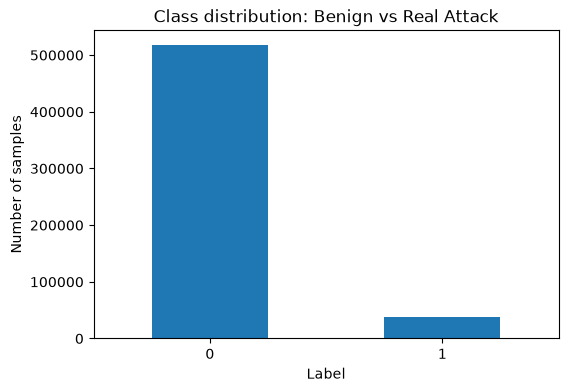

In [7]:
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Class distribution: Benign vs Real Attack")
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()


,count,percentage
traffic_category,,
Benign,347431,62.57
Background,170151,30.64
Probing,23388,4.21
Bruteforce,5884,1.06
Bruteforce-XML,5145,0.93
XMRIGCC CryptoMiner,3279,0.59


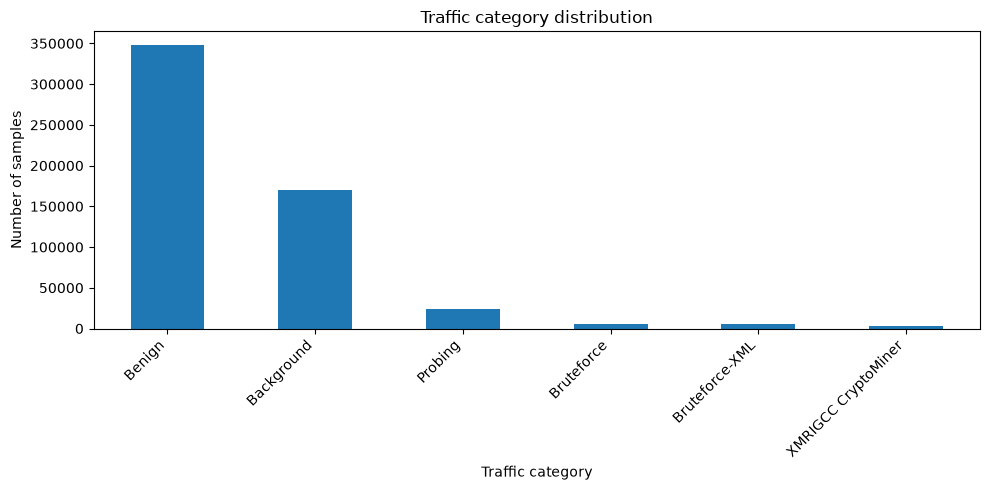

Label,0,1
traffic_category,,
Background,170151,0
Benign,347431,0
Bruteforce,0,5884
Bruteforce-XML,0,5145
Probing,0,23388
XMRIGCC CryptoMiner,0,3279


In [8]:
#traffic_category analysis
if "traffic_category" in df.columns: 
    traffic_summary = pd.DataFrame({
        "count": df["traffic_category"].value_counts(),
        "percentage": (df["traffic_category"].value_counts(normalize=True) * 100).round(2)
    })
    display(traffic_summary) 

    plt.figure(figsize=(10, 5))
    df["traffic_category"].value_counts().plot(kind="bar")
    plt.title("Traffic category distribution")
    plt.xlabel("Traffic category")
    plt.ylabel("Number of samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(pd.crosstab(df["traffic_category"], df["Label"]))
else:
    print("Column 'traffic_category' not found. Skipping traffic category analysis.")


## 5. Quick dataset summary

creates a compact summary of the dataset.


In [9]:
#summary of the dataset.
summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicates": int(df.duplicated().sum()),
    "missing_values_total": int(df.isna().sum().sum()),
    "target_column": "Label",
    "number_of_classes label": int(df["Label"].nunique())
}
#display(df.tail(5))
display(summary)


{'rows': 555278,
 'columns': 88,
 'duplicates': 0,
 'missing_values_total': 0,
 'target_column': 'Label',
 'number_of_classes label': 2}

## 6. Dataset Preparation

define the model input matrix `X` and the target vector `y`.

- `Label` is separated as the target variable.
- Identifier columns are removed.
- Network host fields such as origin/responder identifiers are removed.
- Categorical descriptors such as `traffic_category` are excluded from the numeric baseline model.
- Only numeric features are selected for training.

-Identifiers such as unique IDs, IP-like fields, or dataset-specific indexes can create misleading performance. The model may memorize dataset artifacts instead of learning generalizable traffic behaviour.

-Removing categorical fields simplifies the baseline and reduces leakage risk, but it may also discard useful information. A future improvement could encode selected categorical features using one-hot encoding, but only after verifying that they are legitimate predictors and not leakage fields.

In [10]:
target_col = "Label"

drop_cols = [
    "Unnamed: 0.1",
    "Unnamed: 0",
    "uid",
    "originh",
    "responh",
    "traffic_category",
    "Label"
]

# Removes the specified columns from the DataFrame df to create a new DataFrame X_raw, 
# which will be used as the feature matrix for machine learning. 
# The errors="ignore" parameter ensures that if any of the specified columns are not found in df, 
# no error will be raised, and those columns will simply be ignored.
X_raw = df.drop(columns=drop_cols, errors="ignore")

#Builds the target variable y by selecting the "Label" column from df and converting its data type to integer. 
# This is necessary for machine learning algorithms that require numerical input.
y = df[target_col].astype(int)

# Selects only the numeric columns from X_raw to create a new DataFrame X, 
# which will be used as the feature matrix for machine learning.
X = X_raw.select_dtypes(include=["number"]).copy()

print("Original dataset complete:", df.shape)
print("Original feature matrix shape:", X_raw.shape)
print("Numeric feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of selected numeric features:", X.shape[1])

#display(X.head())
#display(y.head())

Original dataset complete: (555278, 88)
Original feature matrix shape: (555278, 81)
Numeric feature matrix shape: (555278, 81)
Target shape: (555278,)
Number of selected numeric features: 81


## 7. Cleaning missing and infinite values

It prepares numeric features so that scikit-learn models can process them.

**Problem:** ML algorithms usually cannot train with `NaN`, `inf`, or `-inf` values. These values can appear in network-flow datasets due to divisions by zero, missing measurements, extraction errors, or abnormal traffic behaviour.

**Solution used here:**

1. Convert infinite values into missing values.
2. Replace missing values with the median value of each feature.

**Why median:** the median is more robust than the mean when features contain extreme outliers, which is common in traffic-flow data.

**Important limitation:** imputation changes the data. In a final paper, this decision should be documented because preprocessing choices directly affect model performance.

In [11]:
#replaces any infinite values in the DataFrame X with NaN (Not a Number) to 
# handle potential issues during data preprocessing and model training. 
# This is important because infinite values can cause errors or unexpected behavior in machine learning algorithms.
#X = X.replace([np.inf, -np.inf], np.nan) 

#Reports the number of missing values in the feature matrix before and after 
# filling them with the median of each column.
missing_before = int(X.isna().sum().sum())
X = X.fillna(X.median(numeric_only=True))

X = X.replace([np.inf, -np.inf], np.nan)

print("Total missing values:", int(X.isna().sum().sum()))

missing_after = int(X.isna().sum().sum())

print("Missing values before cleaning:", missing_before)
print("Missing values after cleaning:", missing_after)
#display(X)

Total missing values: 0
Missing values before cleaning: 0
Missing values after cleaning: 0


## 8. Exploratory feature analysis

Check which numeric features have the strongest linear association with the target label.

**-A high absolute correlation:**  means that a feature changes consistently with the label. 
This indicates that the feature helps separate benign and malicious flows.


In [12]:
numeric_df = pd.concat([X, y.rename("Label")], axis=1) # Create a DataFrame with numeric features and the target variable

# Calculates the absolute correlation of each numeric feature with the target variable "Label" and sorts them in descending order.
correlations = numeric_df.corr(numeric_only=True)["Label"].abs().sort_values(ascending=False) 
display(correlations.head(16))
#display(numeric_df)
#display(X)

Label                    1.000000
bwd_init_window_size     0.321053
bwd_header_size_max      0.291120
fwd_pkts_payload.std     0.283017
bwd_header_size_min      0.281358
fwd_pkts_payload.max     0.265688
bwd_bulk_rate            0.249869
flow_RST_flag_count      0.244015
flow_SYN_flag_count      0.239297
flow_FIN_flag_count      0.231533
fwd_header_size_max      0.220685
fwd_init_window_size     0.214189
fwd_pkts_payload.avg     0.208203
bwd_pkts_payload.std     0.200748
flow_pkts_payload.std    0.194539
flow_pkts_payload.avg    0.182477
Name: Label, dtype: float64

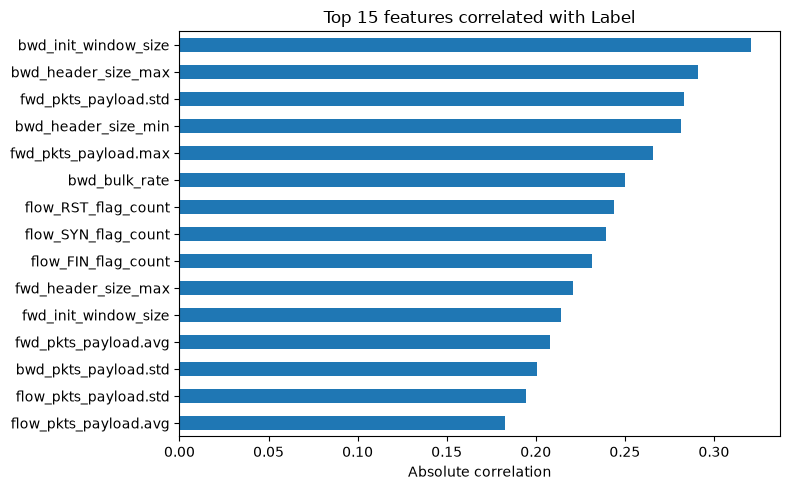

In [13]:
top_corr = correlations.drop("Label", errors="ignore").head(15).sort_values()

plt.figure(figsize=(8, 5))
top_corr.plot(kind="barh")
plt.title("Top 15 features correlated with Label")
plt.xlabel("Absolute correlation")
plt.tight_layout()
plt.show()


**Why this matters for IDS:** feature analysis supports explainability. Instead of treating the model as a black box, we start identifying which traffic characteristics appear relevant for attack detection.

## 9. Train/test split
separates the dataset into training and testing subsets.

** `stratify=y` preserves the class distribution in both train and test subsets. This is important for IDS because class imbalance can distort the evaluation if one split receives proportionally more attacks than the other.


In [14]:

RANDOM_STATE = 42 
# means that the random number generator will produce the same sequence of numbers 
#each time the code is run, ensuring reproducibility of results.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=RANDOM_STATE,stratify=y)# train_test_split splits the dataset into training and testing sets.


print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nDevelopment class distribution:")
display(y_train.value_counts(normalize=True).sort_index().mul(100).rename("train_percentage"))

print("\nTest class distribution:")
display(y_test.value_counts(normalize=True).sort_index().mul(100).rename("test_percentage"))


Training features: (444222, 81)
Testing features: (111056, 81)

Development class distribution:


Label
0    93.211277
1     6.788723
Name: train_percentage, dtype: float64


Test class distribution:


Label
0    93.211533
1     6.788467
Name: test_percentage, dtype: float64

## 10. Scaling for Logistic Regression

standardizes values for Logistic Regression.

**Why scaling is needed:** Logistic Regression is sensitive to feature magnitude. A feature measured in large numerical ranges can dominate another feature measured in smaller ranges, even if it is not more important.

**Data leakage control:** the scaler is fitted only on the training set using `fit_transform`. The test set is transformed using the same scaler with `transform`. This prevents information from the test set from influencing training.

**Why Random Forest is not scaled:** tree-based models split features by thresholds and are generally not sensitive to feature scaling. Therefore, Random Forest is trained with the original numeric values.

In [15]:
scaler = StandardScaler() 
# StandardScaler standardizes features by removing the mean and scaling to unit variance. 
#This is important for many machine learning algorithms that are sensitive to the scale of input features.

X_train_scaled = scaler.fit_transform(X_train) #fits the scaler to the training data and transforms it
X_test_scaled = scaler.transform(X_test) # transforms the test data using the fitted scaler


## 11. Model 1 — Logistic Regression Classifier

Logistic Regression is used as the first baseline model.

**Why this model is useful:**

- It is simple and fast.
- It is interpretable compared with complex models.
- It provides class probabilities through `predict_proba`.
- It is a strong baseline for binary classification.

**Model Interpretation:** Logistic Regression can show whether a linear decision boundary is enough to separate benign and malicious flows. If it performs well, the dataset may contain strong linear patterns. If it performs poorly, more complex models may be required.

**Class imbalance control:** `class_weight="balanced"` increases the penalty for mistakes in the minority class. This is important when attacks are underrepresented or when recall for attacks is operationally critical.

In [16]:
log_model=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=None)# sets up a logistic regression model with specified parameters.

log_model.fit(X_train_scaled, y_train)  #trains the model using the scaled training data and corresponding labels.
#y_train is the target variable (labels) for the training data, and X_train_scaled is the feature matrix for the training data.
#fits the logistic regression model to the scaled training data and corresponding labels, 
# allowing it to learn the relationship between features and the target variable.

y_pred_log = log_model.predict(X_test_scaled) # predicts the labels for the scaled test data using the trained logistic regression model.
y_score_log = log_model.predict_proba(X_test_scaled)[:, 1] # gets the predicted probabilities for the positive class.


accuracy = 100.0 * accuracy_score(y_test, y_pred_log) 
print ("Logistic Regression accuracy (%): " + str(accuracy))

Logistic Regression accuracy (%): 84.59696009220573


## 12. Model 2 — Random Forest Classifier

Random Forest is used as a stronger non-linear baseline.

**Why this model is useful:**

- It combines multiple decision trees.
- It can learn non-linear relationships between network-flow features and labels.
- It is robust for tabular datasets.
- It provides feature-importance values.

**Model Interpretation:** network attacks may not be separable by a simple linear rule. Random Forest can capture interactions such as packet count, duration and byte-rate patterns that jointly indicate malicious behaviour.

**Important risk:** Random Forest can overfit if not tuned correctly. This is why evaluation on the test set and future hyperparameter tuning are required.

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test) # predicts the labels for the test data using the trained random forest model.
y_score_rf = rf_model.predict_proba(X_test)[:, 1] # scores for the positive class (class 1) from the predicted probabilities for the test data using the trained random forest model.

accuracy = 100.0 * accuracy_score(y_test, y_pred_rf)
print ("Random Forest accuracy: " + str(accuracy))


Random Forest accuracy: 87.38294193920184


## 13. Model 3 — Decision Tree Classifier

Decision Tree is added as an interpretable supervised-learning model.

- It creates decision rules that are easy to explain.
- It is suitable for tabular cybersecurity datasets.
- It helps compare a simple interpretable tree against Logistic Regression and Random Forest.
- It can expose which traffic features are used to separate benign and malicious flows.



In [18]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_score_dt = dt_model.predict_proba(X_test)[:, 1] # scores for the positive class (class 1) from the predicted probabilities for the test data using the trained decision tree model.

accuracy = 100.0 * accuracy_score(y_test, y_pred_dt)
print ("Decision Tree accuracy: " + str(accuracy))


Decision Tree accuracy: 85.97104163665178


## 14. Evaluation methodology

This step defines how model performance is measured.

The following metrics are used:

- **Accuracy:** global percentage of correct predictions.
- **Precision:** among predicted attacks, how many were really attacks.
- **Recall:** among real attacks, how many were detected.
- **F1-score:** harmonic balance between precision and recall.
- **ROC-AUC:** ranking quality across decision thresholds.
- **PR-AUC:** especially useful when the positive class is imbalanced.

**IDS-specific priority:** recall for the attack class is operationally critical. A false negative means an attack was missed. However, precision also matters because too many false positives create alert fatigue and reduce SOC efficiency.


In [19]:
def evaluate_model(model_name, y_true, y_pred, y_score):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    }

    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return results


### Model comparison table

The table below consolidates the performance of all models into one view.

**How to use this table:**

- Start with recall to understand detection capability.
- Check precision to estimate alert quality.
- Use F1-score to compare the precision/recall balance.
- Use ROC-AUC and PR-AUC to evaluate probability ranking quality.

For the final report, select the model based on IDS risk, not only on the highest accuracy.

In [20]:
results_log = evaluate_model("Logistic Regression", y_test, y_pred_log, y_score_log)
results_dt = evaluate_model("Decision Tree", y_test, y_pred_dt, y_score_dt)
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_score_rf)

results_df = pd.DataFrame([results_log, results_dt, results_rf])
results_df

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    103517
           1       0.31      0.99      0.47      7539

    accuracy                           0.85    111056
   macro avg       0.65      0.91      0.69    111056
weighted avg       0.95      0.85      0.88    111056

Confusion Matrix:
[[86468 17049]
 [   57  7482]]
=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      0.85      0.92    103517
           1       0.33      1.00      0.49      7539

    accuracy                           0.86    111056
   macro avg       0.66      0.92      0.70    111056
weighted avg       0.95      0.86      0.89    111056

Confusion Matrix:
[[87951 15566]
 [   14  7525]]
=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.91      0.93    103517
           1       0.23      0.38      0.29      7539

    accuracy

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.845970,0.305002,0.992439,0.466604,0.934230,0.377356
1,Decision Tree,0.859710,0.325885,0.998143,0.491348,0.944641,0.419071
2,Random Forest,0.873829,0.233292,0.375514,0.287791,0.898353,0.235913


## 15. Confusion matrices

A confusion matrix converts the predictions into operational IDS outcomes. In the matrices below, scikit-learn uses the structure `[[TN, FP], [FN, TP]]`:

- **True Negative (TN):** benign traffic correctly ignored.
- **False Positive (FP):** benign traffic incorrectly raised as an attack alert.
- **False Negative (FN):** a real attack missed by the IDS.
- **True Positive (TP):** a real attack correctly detected.

### Interpretation of the observed results

| Model | TN | FP | FN | TP | IDS interpretation |
|---|---:|---:|---:|---:|---|
| Logistic Regression | 86,468 | 17,049 | 57 | 7,482 | Detects almost every attack, but generates a large number of false alerts. |
| Decision Tree | 87,951 | 15,566 | 14 | 7,525 | Best attack detection and fewer false positives than Logistic Regression. |
| Random Forest | 94,213 | 9,304 | 4,708 | Produces fewer false alerts, but misses most attacks and is therefore high-risk for IDS use. |

The **Decision Tree provides the strongest operational result at the current decision rule**. It detects **7,525 of 7,539 attacks**, corresponding to **99.81% recall**, and misses only **14 attacks**. Its main weakness is the **15,566 false positives**, which would still create a significant workload for security analysts.

Logistic Regression also achieves very high attack recall (**99.24%**) but misses **57 attacks** and generates **17,049 false positives**. It is therefore slightly weaker than the Decision Tree both in detection and alert quality.

The Random Forest obtains the highest overall accuracy, but this is misleading because the dataset is dominated by benign traffic. It misses **4,708 of 7,539 attacks**, giving only **37.55% recall**. From an intrusion-detection perspective, this level of false negatives is unacceptable even though the model correctly classifies more benign flows.

**Operational conclusion:** false negatives carry the highest security risk because they represent attacks that pass undetected. Based on the confusion matrices, the Decision Tree is the best of the three models for attack detection, while threshold tuning or additional model calibration would be required to reduce its false-positive burden.


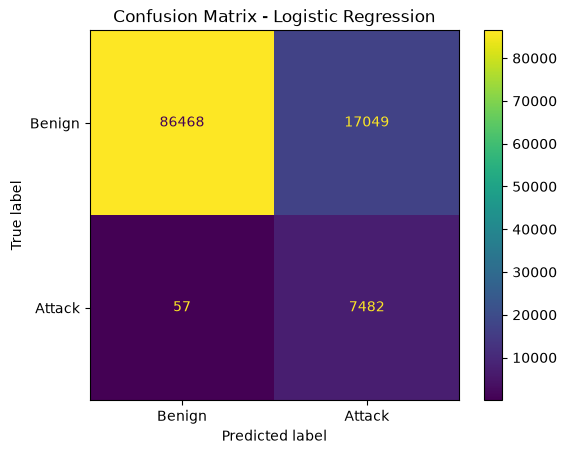

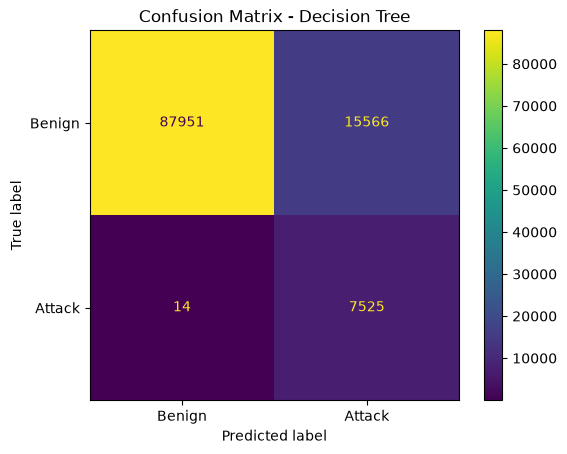

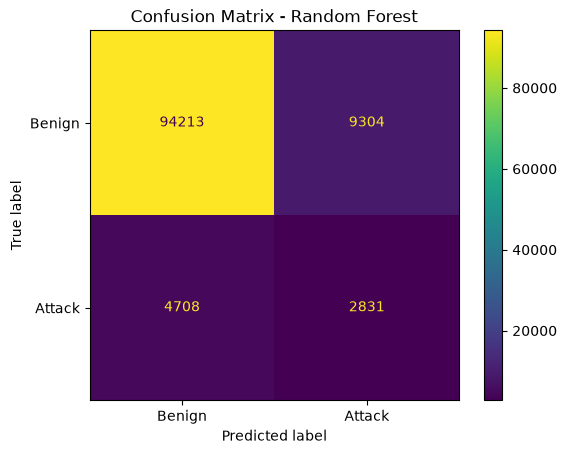

In [21]:

for model_name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Attack"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()



## 16. ROC and Precision-Recall curves

These curves compare the models across multiple classification thresholds instead of evaluating only the default decision rule.

- The **ROC curve** plots the true-positive rate against the false-positive rate. A curve closer to the upper-left corner and a larger ROC-AUC indicate stronger overall class separation.
- The **Precision-Recall curve** focuses on attack precision and attack recall. It is more informative for this dataset because attacks represent only about **6.79%** of the test samples.

ROC-AUC measures how well a model ranks attacks above benign traffic across thresholds. PR-AUC measures how effectively the model preserves attack precision while increasing attack recall. For IDS model selection, PR-AUC and the operating point on the Precision-Recall curve are particularly important because they expose the false-alert cost hidden by class imbalance.


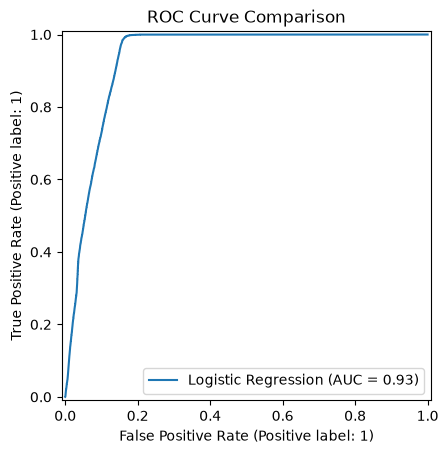

ROC Curve for Logistic Regression displayed.


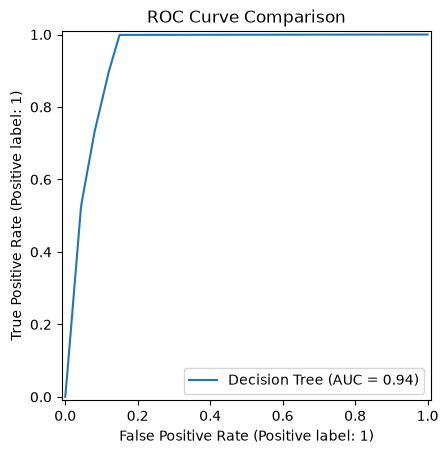

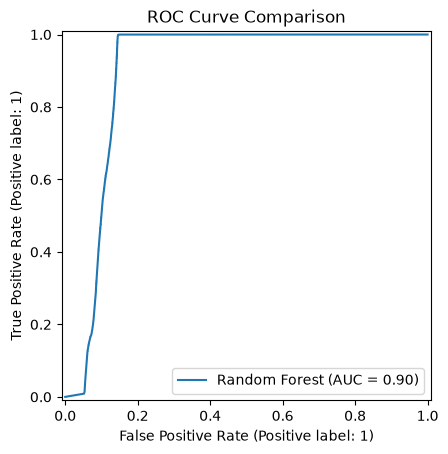

In [22]:

RocCurveDisplay.from_predictions(y_test, y_score_log, name="Logistic Regression")
plt.title("ROC Curve Comparison")
plt.show()
print("ROC Curve for Logistic Regression displayed.")

RocCurveDisplay.from_predictions(y_test, y_score_dt, name="Decision Tree")
plt.title("ROC Curve Comparison")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_score_rf, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.show() 



### ROC curve interpretation

The **Decision Tree achieved the highest ROC-AUC, 0.9446**, indicating the strongest overall ability to rank attack flows above benign flows across different thresholds. Logistic Regression follows closely with a **ROC-AUC of 0.9342**, while Random Forest records the weakest result at **0.8984**.

All three ROC-AUC values are substantially above 0.5, so every model performs better than random ranking. However, the ROC curve can appear optimistic in an imbalanced dataset because the large number of benign samples makes the false-positive rate look relatively small even when the absolute number of false alerts is high.

This limitation is visible in the confusion matrices: Logistic Regression and the Decision Tree both have strong ROC-AUC values, but they still generate **17,049** and **15,566** false positives respectively at the current decision rule. Therefore, ROC-AUC should not be used alone to select the final IDS model.


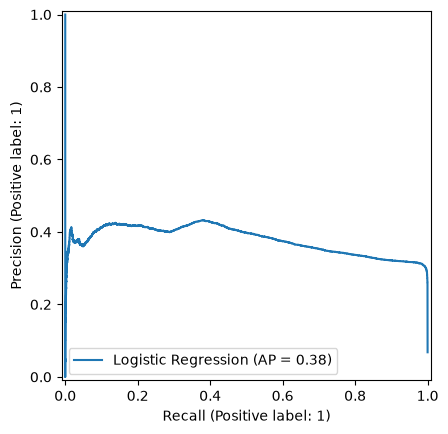

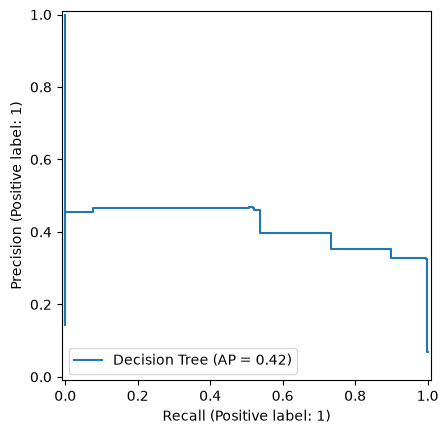

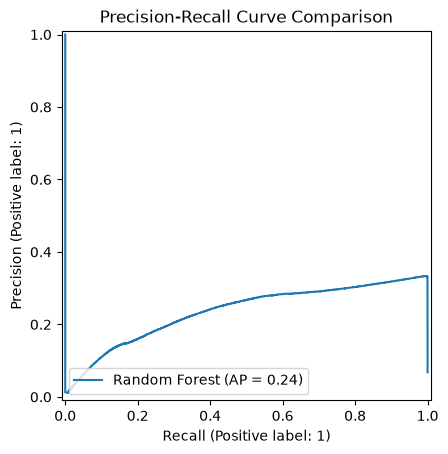

In [23]:


PrecisionRecallDisplay.from_predictions(y_test, y_score_log, name="Logistic Regression")
PrecisionRecallDisplay.from_predictions(y_test, y_score_dt, name="Decision Tree")
PrecisionRecallDisplay.from_predictions(y_test, y_score_rf, name="Random Forest")
plt.title("Precision-Recall Curve Comparison")
plt.show()


### Precision-Recall curve interpretation

The Precision-Recall results confirm the same model ranking but provide a more realistic view of attack detection quality:

| Model | PR-AUC | Interpretation |
|---|---:|---|
| Decision Tree | **0.4191** | Best balance between attack precision and recall across thresholds. |
| Logistic Regression | **0.3774** | Strong recall capability, but lower alert precision than the Decision Tree. |
| Random Forest | **0.2359** | Weakest attack-focused performance and poor recall at the current decision rule. |

The attack prevalence in the test set is approximately **0.0679**, so a non-informative classifier would have a Precision-Recall baseline near **6.79%**. All three models outperform this baseline, but the Decision Tree provides the largest improvement.

Even for the Decision Tree, a PR-AUC of **0.4191** shows that high recall is obtained with limited precision. At the current operating point, only **32.59%** of its attack alerts are correct, meaning that roughly two out of every three attack alerts are false positives. Logistic Regression has a similar issue, with **30.50% precision**. The Random Forest reduces the number of alerts but fails to detect enough attacks.

**Overall interpretation:** the Decision Tree is the strongest candidate because it leads in ROC-AUC, PR-AUC, recall and F1-score. Nevertheless, deployment would require threshold optimisation and validation against the organisation's acceptable trade-off between missed attacks and analyst workload. The Random Forest's higher accuracy should not drive model selection because its low attack recall creates a material security blind spot.


## 17. Decision Tree feature importance

This step identifies which features contributed most to the Decision Tree decisions.

In [24]:
dt_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

dt_feature_importance.head(15)

,Feature,Importance
5,fwd_data_pkts_tot,0.712169
79,bwd_init_window_size,0.144855
47,bwd_iat.min,0.041609
54,flow_iat.tot,0.031383
17,flow_FIN_flag_count,0.021692
28,fwd_pkts_payload.max,0.010271
80,fwd_last_window_size,0.007682
2,flow_duration,0.006603
66,fwd_bulk_rate,0.002928
27,fwd_pkts_payload.min,0.002819


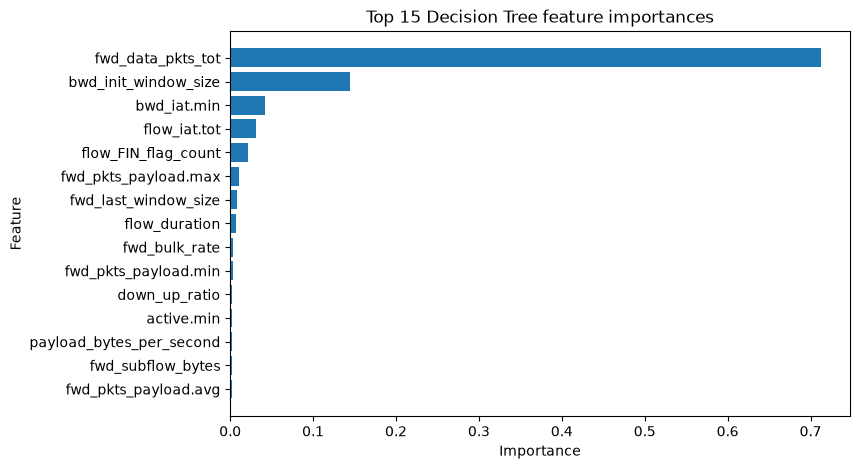

In [25]:
dt_top_features = dt_feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(dt_top_features["Feature"], dt_top_features["Importance"])
plt.title("Top 15 Decision Tree feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 18. Random Forest feature importance

This step identifies which features contributed most to Random Forest decisions



In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance.head(15))


,Feature,Importance
60,fwd_subflow_bytes,0.068364
46,fwd_iat.std,0.058235
5,fwd_data_pkts_tot,0.055313
43,fwd_iat.max,0.052493
70,active.tot,0.050327
79,bwd_init_window_size,0.046848
3,fwd_pkts_tot,0.046132
29,fwd_pkts_payload.tot,0.036277
2,flow_duration,0.035802
44,fwd_iat.tot,0.032809


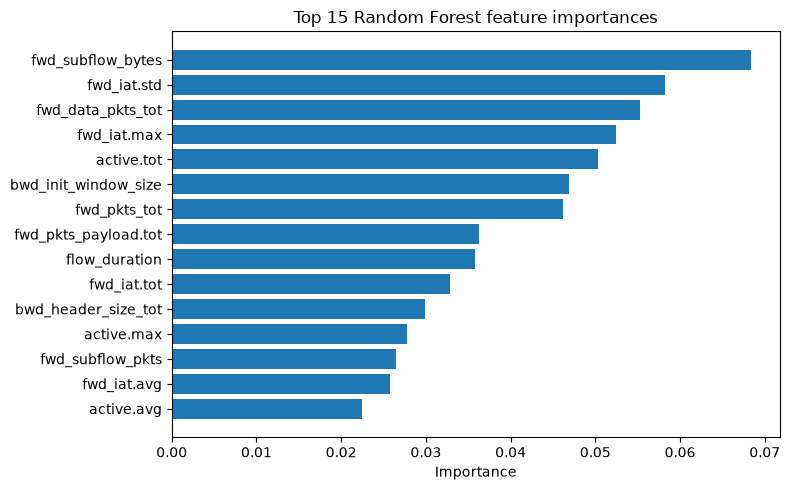

In [27]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 19. Cybersecurity interpretation of results

The final model should not be selected only by accuracy. In an IDS, the business and security impact of each error type is different:

- **False negatives** mean malicious flows are not detected. This can allow compromise, lateral movement, data leakage, or persistence.
- **False positives** mean benign flows are flagged as malicious. This increases alert fatigue and can overload SOC analysts.

**Decision logic:**

- If recall is low, the model is risky because attacks are missed.
- If precision is low, the model may be noisy and expensive to operate.
- If F1-score is balanced, the model may be operationally more sustainable.
- If PR-AUC is strong, the model ranks attack traffic well even under imbalance.

A model with high accuracy but weak attack recall may look good academically but fail operationally.

## 20. Results discussion

This section should be completed after running the notebook and observing the actual metrics.

Recommended interpretation logic:

- **Logistic Regression** is the linear baseline. It is useful to understand whether the problem can be solved with a simple decision boundary.
- **Decision Tree** is the interpretable non-linear model. It can reveal simple rules but may overfit if the tree is too deep.
- **Random Forest** is the ensemble model. It normally improves robustness by combining many decision trees, but its operational value must still be judged by recall, precision and false negatives.

For an IDS, the best model is not automatically the one with the highest accuracy. The key business/security question is: **which model detects the highest number of attacks while keeping false alarms operationally manageable?**

## References

- HIKARI2021 / ALLFLOWMETER_HIKARI2021 dataset documentation.
- Scikit-learn documentation: supervised learning, Logistic Regression, Random Forest and model evaluation metrics.
- Rui Fernandes, *AI for Cybersecurity* course materials.
- Rui Fernandes, *Scientific Writing - Introduction* course materials.

